# Library Import

In [2]:
import numpy as np
import librosa
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [3]:


# ── Dataset Path ──
dataset_path = "recordings"
class_names = ['0', '1', '2', '3']  # 4 class
label_names = ['zero', 'one', 'two', 'three']

# ── MFCC Feature Extraction ──
def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

# ── Data Load ──
X, y = [], []
for file in os.listdir(dataset_path):
    if file.endswith(".wav"):
        label = file.split("_")[0]
        if label in class_names:
            path = os.path.join(dataset_path, file)
            mfcc = extract_mfcc(path)
            X.append(mfcc)
            y.append(class_names.index(label))

X = np.array(X)
y = np.array(y)
print("Data shape:", X.shape)
print("Labels:", np.unique(y, return_counts=True))

# ── Train Test Split ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training:", X_train.shape, "Testing:", X_test.shape)

# ── ANN Model ──
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(40,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')  # 4 class
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ── Train ──
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

c:\Users\User\anaconda3\envs\uzzal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data shape: (1200, 40)
Labels: (array([0, 1, 2, 3]), array([300, 300, 300, 300]))
Training: (960, 40) Testing: (240, 40)


c:\Users\User\anaconda3\envs\uzzal\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,908 (202.77 KB)

 Trainable params: 51,908 (202.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.2677 - loss: 11.3933 - val_accuracy: 0.3000 - val_loss: 1.9046
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2927 - loss: 4.2632 - val_accuracy: 0.2667 - val_loss: 1.5581
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3146 - loss: 2.8354 - val_accuracy: 0.2708 - val_loss: 1.4661
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3031 - loss: 2.2465 - val_accuracy: 0.4125 - val_loss: 1.3454
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3229 - loss: 1.8147 - val_accuracy: 0.2917 - val_loss: 1.3508
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3208 - loss: 1.7156 - val_accuracy: 0.3708 - val_loss: 1.2364
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3719 - loss: 1.5058 - val_accuracy: 0.5292 - val_loss: 1.1351
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3562 - loss: 1.4817 - val_accuracy: 0.5000 - val_los

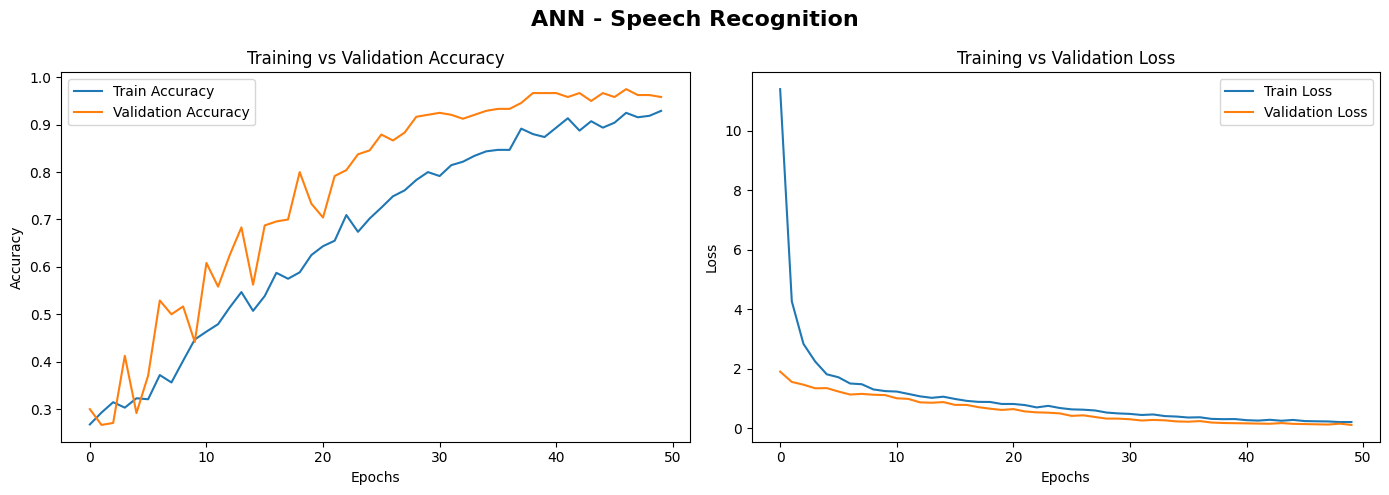

In [4]:
# ── Loss & Accuracy Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training vs Validation Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()

# Training vs Validation Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()

plt.suptitle('ANN - Speech Recognition', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


Training Accuracy : 98.54 %
Testing Accuracy  : 95.83 %
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Classification Report:
              precision    recall  f1-score   support

        zero       0.94      0.98      0.96        62
         one       1.00      1.00      1.00        60
         two       0.96      0.92      0.94        60
       three       0.93      0.93      0.93        58

    accuracy                           0.96       240
   macro avg       0.96      0.96      0.96       240
weighted avg       0.96      0.96      0.96       240



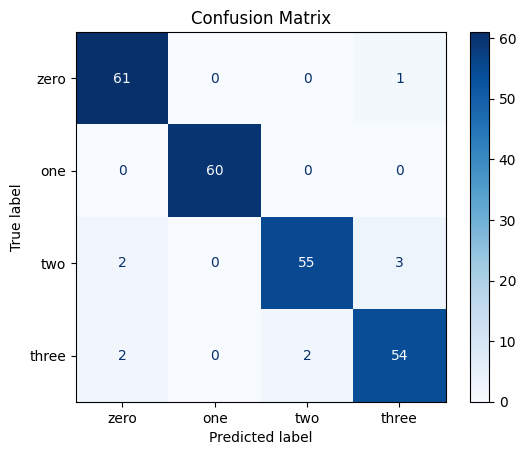

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


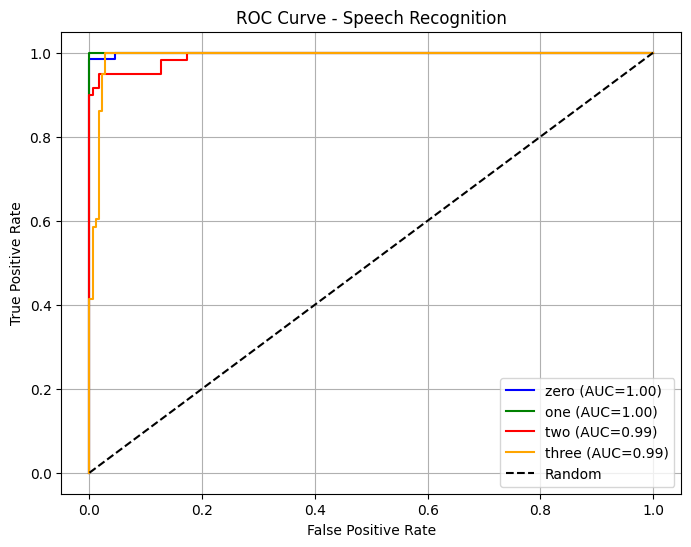

In [5]:


# ── Accuracy ──
train_acc = model.evaluate(X_train, y_train, verbose=0)[1] * 100
test_acc  = model.evaluate(X_test,  y_test,  verbose=0)[1] * 100
print(f"Training Accuracy : {train_acc:.2f} %")
print(f"Testing Accuracy  : {test_acc:.2f} %")

# ── Classification Report ──
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


# ── ROC Curve ──
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_score    = model.predict(X_test)
colors     = ['blue', 'green', 'red', 'orange']

plt.figure(figsize=(8, 6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{label_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Speech Recognition')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



In [ ]:
# ── Sample Prediction ──
print("\n===== Sample Prediction =====")
print(f"{'Index':<8} {'Actual':<12} {'Predicted':<12} {'Result'}")
print("-" * 45)
indices = np.random.choice(len(X_test), 10, replace=False)
for idx in indices:
    actual    = label_names[y_test[idx]]
    predicted = label_names[np.argmax(model.predict(X_test[idx:idx+1], verbose=0))]
    result    = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{idx:<8} {actual:<12} {predicted:<12} {result}")